# Lee–Carter Mortality Forecasting
### Australia — Male and Female, 1950–2019
*Data: Human Mortality Database (HMD), central death rates*

---

## The Lee–Carter Model

Lee & Carter (1992) decompose the log central death rate as

$$\boxed{\ln m(x,t) = a_x + b_x \, k_t + \varepsilon_{x,t}}$$

| Symbol | Interpretation |
|--------|---------------|
| $a_x$ | Age pattern — average log-mortality at age $x$ across all years |
| $b_x$ | Age sensitivity — how strongly age $x$ responds to a unit change in $k_t$ |
| $k_t$ | Mortality index — single number per year summarising overall mortality level |
| $\varepsilon_{x,t}$ | Residual, assumed i.i.d. $\mathcal{N}(0,\sigma^2)$ |

### Identifiability constraints

$$\sum_x b_x = 1, \qquad \sum_t k_t = 0$$

### Estimation by SVD

1. $a_x = \frac{1}{T}\sum_t \ln m(x,t)$ — time average of log-rates.
2. Centre: $Z_{x,t} = \ln m(x,t) - a_x$.
3. SVD: $Z = USV^\top$. Leading rank-1 term gives $b_x \propto U_{:,0}$, $k_t \propto s_1 V^\top_{0,:}$.
4. Rescale: divide $b_x$ by $\sum b_x$ so $\sum b_x = 1$; multiply $k_t$ by the same factor.

### Forecasting $k_t$

$$k_t = k_{t-1} + d + \sigma_k\varepsilon_t, \quad \varepsilon_t \overset{iid}{\sim}\mathcal{N}(0,1)$$

Random walk with drift $d$ (average annual mortality change). Projected rates:
$\hat{m}(x,t) = \exp(a_x + b_x \hat{k}_t)$.

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.grid": True, "axes.facecolor": "#EAEAF2",
    "grid.color": "white", "grid.linewidth": 0.8,
    "figure.facecolor": "white",
    "legend.framealpha": 0.9,
})

COUNTRY   = "AUS"
COUNTRY_NAME = "Australia"
YEAR_MIN  = 1950
YEAR_MAX  = 2019
AGE_MIN   = 0
AGE_MAX   = 99
H_FORE    = 30    # forecast horizon (years)
TRAIN_END = 2000  # backtest split

SEX_COLOR = {"male": "#1f77b4", "female": "#e377c2"}
SEX_LABEL = {"male": "Male", "female": "Female"}

## 2. Data Loading

HMD central death rates $m(x,t)$ stored as `data/{CODE}_{sex}.parquet`.
Each file is an Age × Year DataFrame of $m_{x,t}$ values.
We filter to ages 0–99 and years 1950–2019.

In [2]:
def load_hmd(code, sex, age_min=AGE_MIN, age_max=AGE_MAX,
             year_min=YEAR_MIN, year_max=YEAR_MAX):
    path = os.path.join("data", f"{code}_{sex}.parquet")
    df   = pd.read_parquet(path)
    df   = df.loc[age_min:age_max,
                  [y for y in df.columns if year_min <= y <= year_max]]
    return df

mxt = {}
for sex in ["male", "female"]:
    mxt[sex] = load_hmd(COUNTRY, sex)
    df = mxt[sex]
    print(f"{SEX_LABEL[sex]:8s}: ages {df.index[0]}-{df.index[-1]}, "
          f"years {df.columns[0]}-{df.columns[-1]}, "
          f"shape {df.shape}")

Male    : ages 0-99, years 1950-2019, shape (100, 70)
Female  : ages 0-99, years 1950-2019, shape (100, 70)


## 3. Exploratory Analysis

- **Left:** $\ln m(x,t)$ heatmap — age rises upward, time runs right; lighter = lower mortality.
- **Middle:** Age profiles for selected years — overall level drops over time.
- **Right:** Time trends for selected ages — all declining, with steeper drops at mid-ages.

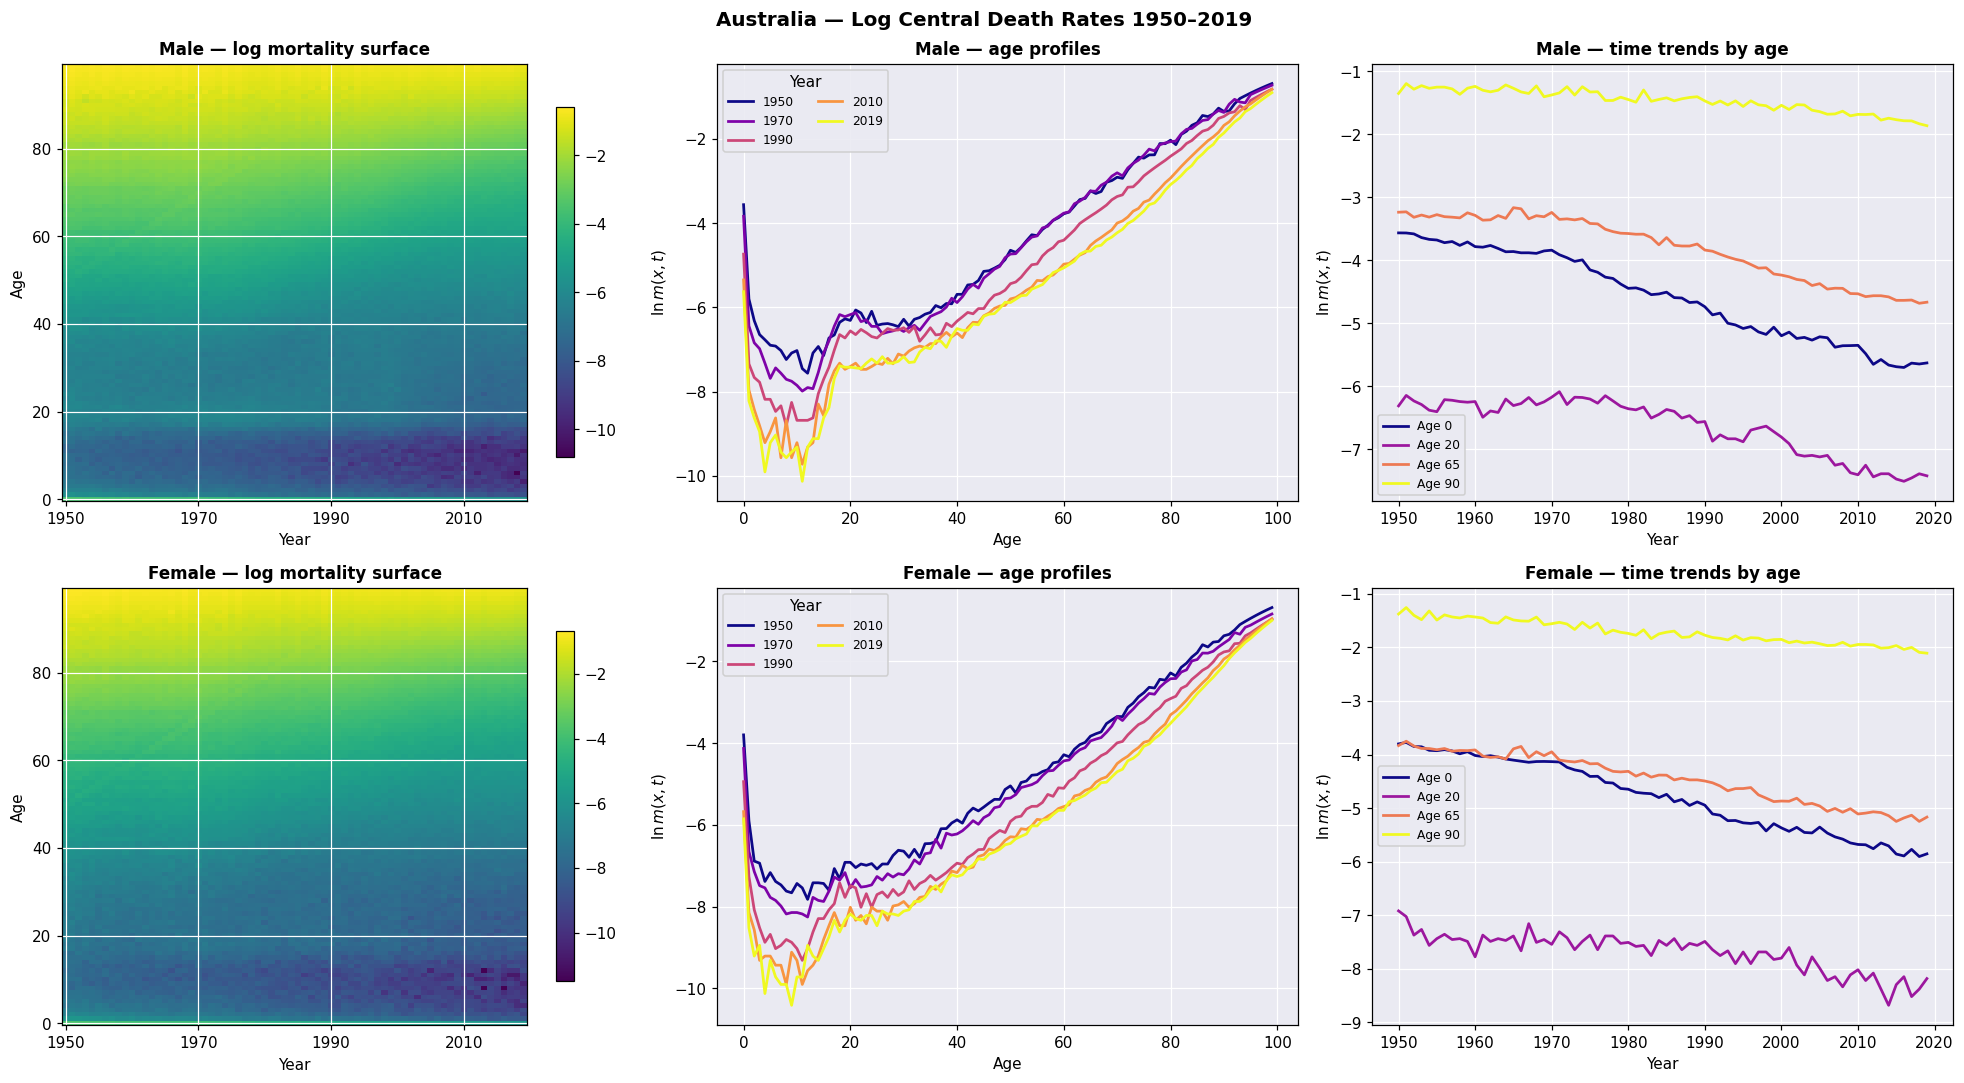

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
profile_years = [1950, 1970, 1990, 2010, 2019]
trend_ages    = [0, 20, 65, 90]
pc = plt.get_cmap("plasma")

for si, sex in enumerate(["male", "female"]):
    df  = mxt[sex]
    lmx = np.log(df.values)
    ages_v = df.index.to_numpy()
    yrs_v  = df.columns.to_numpy()
    ye = np.arange(yrs_v[0],  yrs_v[-1]+2)  - 0.5
    ae = np.arange(ages_v[0], ages_v[-1]+2) - 0.5

    ax = axes[si]
    # Heatmap
    mesh = ax[0].pcolormesh(ye, ae, lmx, cmap="viridis")
    fig.colorbar(mesh, ax=ax[0], shrink=0.8)
    ax[0].set_title(f"{SEX_LABEL[sex]} — log mortality surface")
    ax[0].set_xlabel("Year"); ax[0].set_ylabel("Age")
    ax[0].set_xticks(yrs_v[::20]); ax[0].set_yticks(ages_v[::20])

    # Age profiles
    for i, yr in enumerate(profile_years):
        c = pc(i / (len(profile_years)-1))
        ax[1].plot(ages_v, np.log(df[yr].values), color=c, lw=1.8, label=str(yr))
    ax[1].set_title(f"{SEX_LABEL[sex]} — age profiles")
    ax[1].set_xlabel("Age"); ax[1].set_ylabel(r"$\ln m(x,t)$")
    ax[1].legend(title="Year", fontsize=8, ncol=2)

    # Time trends
    for i, age in enumerate(trend_ages):
        c = pc(i / (len(trend_ages)-1))
        ax[2].plot(yrs_v, np.log(df.loc[age].values), color=c, lw=1.8, label=f"Age {age}")
    ax[2].set_title(f"{SEX_LABEL[sex]} — time trends by age")
    ax[2].set_xlabel("Year"); ax[2].set_ylabel(r"$\ln m(x,t)$")
    ax[2].legend(fontsize=8)

plt.suptitle(f"{COUNTRY_NAME} — Log Central Death Rates {YEAR_MIN}–{YEAR_MAX}",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Core Functions

### 4.1 Lee-Carter SVD Estimation

**Sign convention fix:** check sign of $\sum b_x$ *before* normalizing, not after.
After `bx /= bx.sum()`, the sum is always +1 so a post-hoc check never fires.

In [4]:
def fit_lee_carter(mx_df):
    """
    Fit LC by SVD.  Returns ax, bx, kt as Series with proper index.
    Sign check comes BEFORE normalisation (otherwise bx.sum()=1 always passes).
    """
    M   = np.log(mx_df.values)
    ax  = M.mean(axis=1)
    Z   = M - ax[:, None]

    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    bx = U[:, 0].copy()
    kt = S[0] * Vt[0, :].copy()

    # Sign fix BEFORE normalising
    if bx.sum() < 0:
        bx, kt = -bx, -kt

    # Constraint: sum(bx)=1
    sc = bx.sum()
    bx /= sc;  kt *= sc

    # Centering: sum(kt)=0 (already ~0 from SVD; explicit for float precision)
    kt -= kt.mean()

    return {
        "ax": pd.Series(ax, index=mx_df.index),
        "bx": pd.Series(bx, index=mx_df.index),
        "kt": pd.Series(kt, index=mx_df.columns),
        "var_explained": float(S[0]**2 / (S**2).sum()),
    }

### 4.2 Period Life Table and $e_0$

Standard Chiang (1984) period life table for $n=1$ year intervals.

**Age-0 fraction** $a_0$ uses the Andreev-Kingkade (2015) formula — what HMD uses — which
adjusts $a_0$ based on the level of infant mortality $m_0$:

$$a_0 = \begin{cases}
0.045 + 2.684\,m_0 & m_0 < 0.107\quad\text{(male)}\\
0.330                & m_0 \ge 0.107\quad\text{(male)}
\end{cases}
\qquad
a_0 = \begin{cases}
0.053 + 2.800\,m_0 & m_0 < 0.107\quad\text{(female)}\\
0.350                & m_0 \ge 0.107\quad\text{(female)}
\end{cases}$$

This is more accurate than a fixed constant, especially across the wide range of infant
mortality rates seen from 1950 (high) to 2019 (low).

$$L_{99} = \frac{l_{99}}{m_{99}} \qquad \text{(constant-force open interval)}$$

In [5]:
def a0_andreev(m0, sex):
    """Andreev-Kingkade (2015) age-0 fraction — formula used by HMD."""
    if sex == "male":
        return 0.330 if m0 >= 0.107 else 0.045 + 2.684 * m0
    else:
        return 0.350 if m0 >= 0.107 else 0.053 + 2.800 * m0

def life_expectancy(mx_vec, sex="male"):
    mx  = np.asarray(mx_vec, dtype=float)
    A   = len(mx)
    a   = np.full(A, 0.5)
    a[0] = a0_andreev(mx[0], sex)       # sex-specific, rate-adjusted a0
    qx  = mx / (1.0 + (1.0 - a) * mx)
    qx  = np.minimum(qx, 1.0);  qx[-1] = 1.0
    lx  = np.cumprod(np.concatenate([[1.0], 1.0 - qx[:-1]]))
    dx  = lx * qx
    Lx  = np.empty(A)
    Lx[:-1] = lx[1:] + a[:-1] * dx[:-1]   # Chiang: L_x = l_{x+1} + a_x * d_x
    Lx[-1]  = lx[-1] / mx[-1]              # open interval: constant-force
    Tx  = np.cumsum(Lx[::-1])[::-1]
    return Tx[0] / lx[0]

## 5. Model Fitting

In [6]:
lc = {}
for sex in ["male", "female"]:
    lc[sex] = fit_lee_carter(mxt[sex])
    l = lc[sex]
    print(f"{SEX_LABEL[sex]:8s}: var_explained={l['var_explained']:.1%}  "
          f"sum(bx)={l['bx'].sum():.6f}  sum(kt)={l['kt'].sum():.2e}")

Male    : var_explained=93.0%  sum(bx)=1.000000  sum(kt)=-8.53e-14
Female  : var_explained=91.3%  sum(bx)=1.000000  sum(kt)=2.27e-13


### 5.1 Estimated Parameters

- **$a_x$** — classic age-mortality curve (J-shape: infant peak, accident hump ~20s, exponential rise from 40+)
- **$b_x$** — largest at infant/child ages where most historical improvement occurred; smallest at very old ages
- **$k_t$** — declines near-linearly, justifying the RWD forecast

Female mortality is lower at all ages ($a_x$ shifted down). Female $b_x$ typically shows relatively
more improvement at middle ages compared to males.

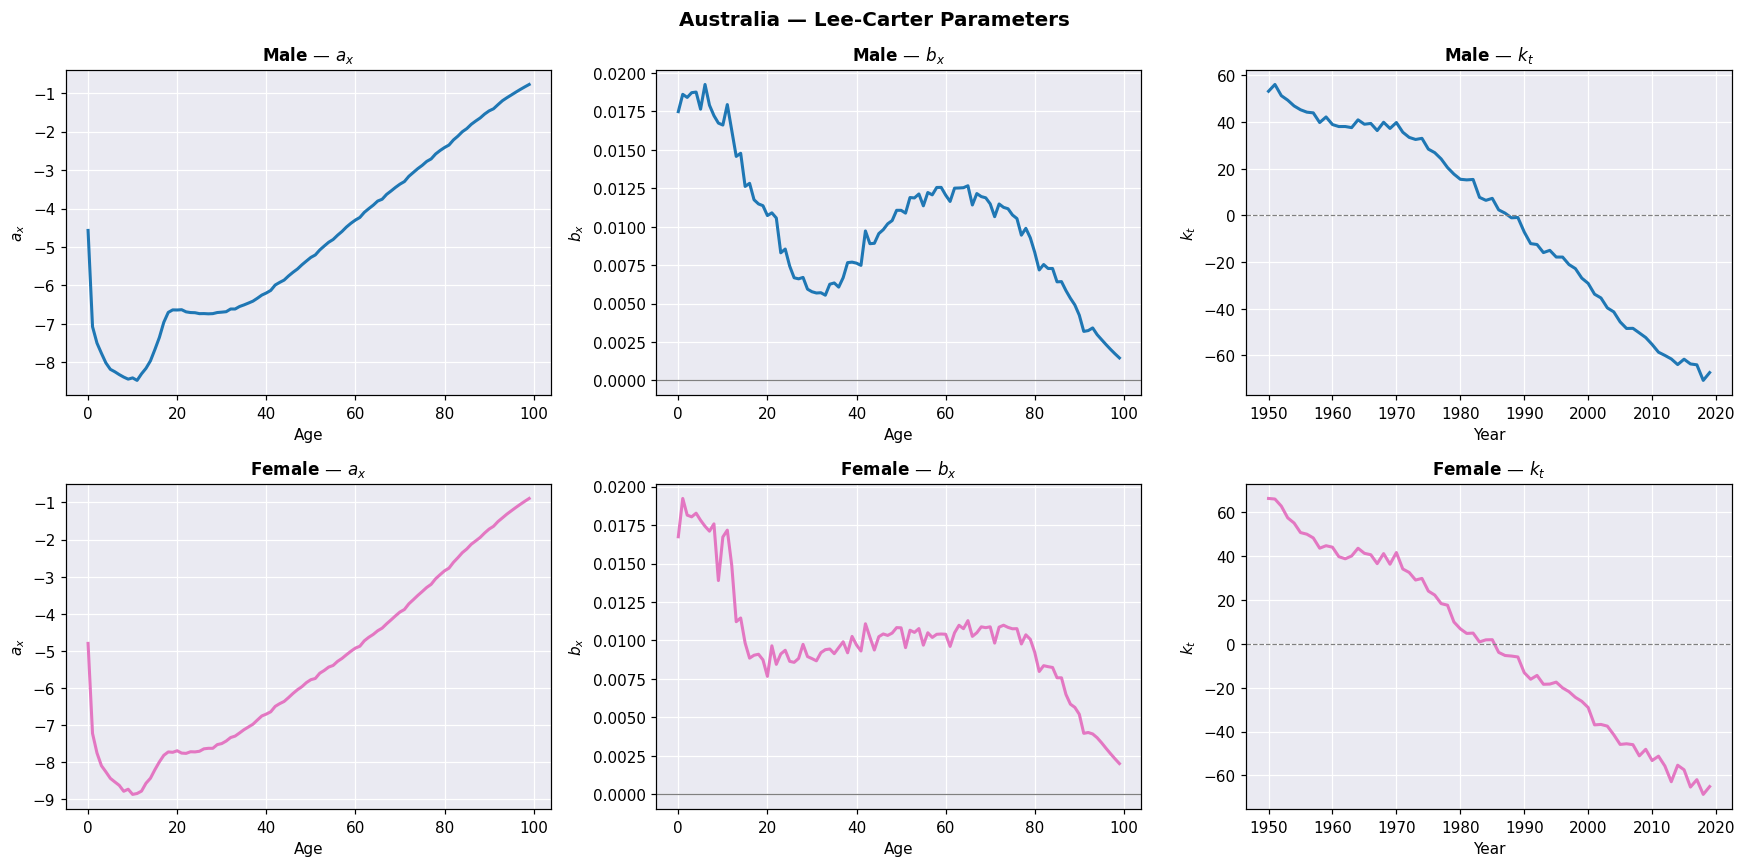

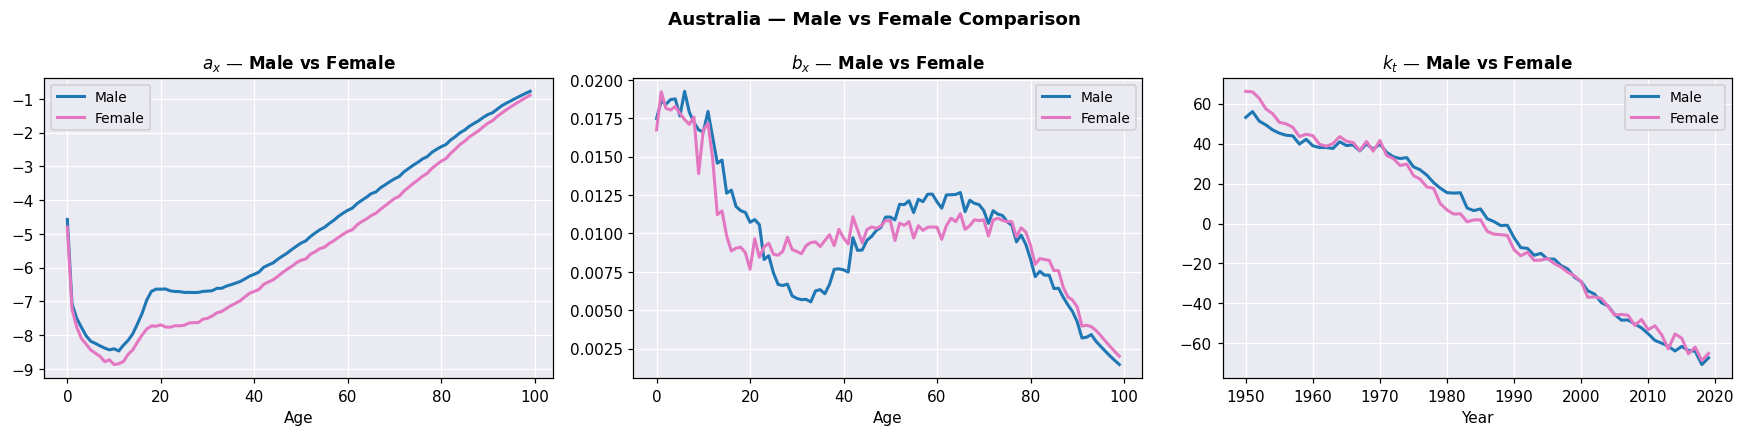

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for si, sex in enumerate(["male", "female"]):
    l   = lc[sex]
    col = SEX_COLOR[sex]
    ax  = axes[si]

    ax[0].plot(l["ax"].index, l["ax"].values, color=col, lw=2)
    ax[0].set_title(f"{SEX_LABEL[sex]} — $a_x$")
    ax[0].set_xlabel("Age"); ax[0].set_ylabel(r"$a_x$")

    ax[1].plot(l["bx"].index, l["bx"].values, color=col, lw=2)
    ax[1].axhline(0, color="grey", lw=0.8)
    ax[1].set_title(f"{SEX_LABEL[sex]} — $b_x$")
    ax[1].set_xlabel("Age"); ax[1].set_ylabel(r"$b_x$")

    ax[2].plot(l["kt"].index, l["kt"].values, color=col, lw=2)
    ax[2].axhline(0, color="grey", lw=0.8, ls="--")
    ax[2].set_title(f"{SEX_LABEL[sex]} — $k_t$")
    ax[2].set_xlabel("Year"); ax[2].set_ylabel(r"$k_t$")

plt.suptitle(f"{COUNTRY_NAME} — Lee-Carter Parameters", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Side-by-side overlay
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = [r"$a_x$", r"$b_x$", r"$k_t$"]
keys   = ["ax", "bx", "kt"]
for ai, (key, lbl) in enumerate(zip(keys, labels)):
    for sex in ["male", "female"]:
        axes[ai].plot(lc[sex][key].index, lc[sex][key].values,
                      color=SEX_COLOR[sex], lw=2, label=SEX_LABEL[sex])
    axes[ai].set_title(f"{lbl} — Male vs Female")
    axes[ai].set_xlabel("Age" if key != "kt" else "Year")
    axes[ai].legend(fontsize=9)
plt.suptitle(f"{COUNTRY_NAME} — Male vs Female Comparison", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Diagnostics

Residual matrix $R_{x,t} = \ln m(x,t) - a_x - b_x k_t$.
If the single-factor model is adequate, this should be structureless noise —
no visible pattern in the heatmap, symmetric near-normal distribution.

Male    : residual mean=-0.00000  std=0.1173  RMSE=0.1173  skew=-0.352
Female  : residual mean=-0.00000  std=0.1305  RMSE=0.1305  skew=-1.287


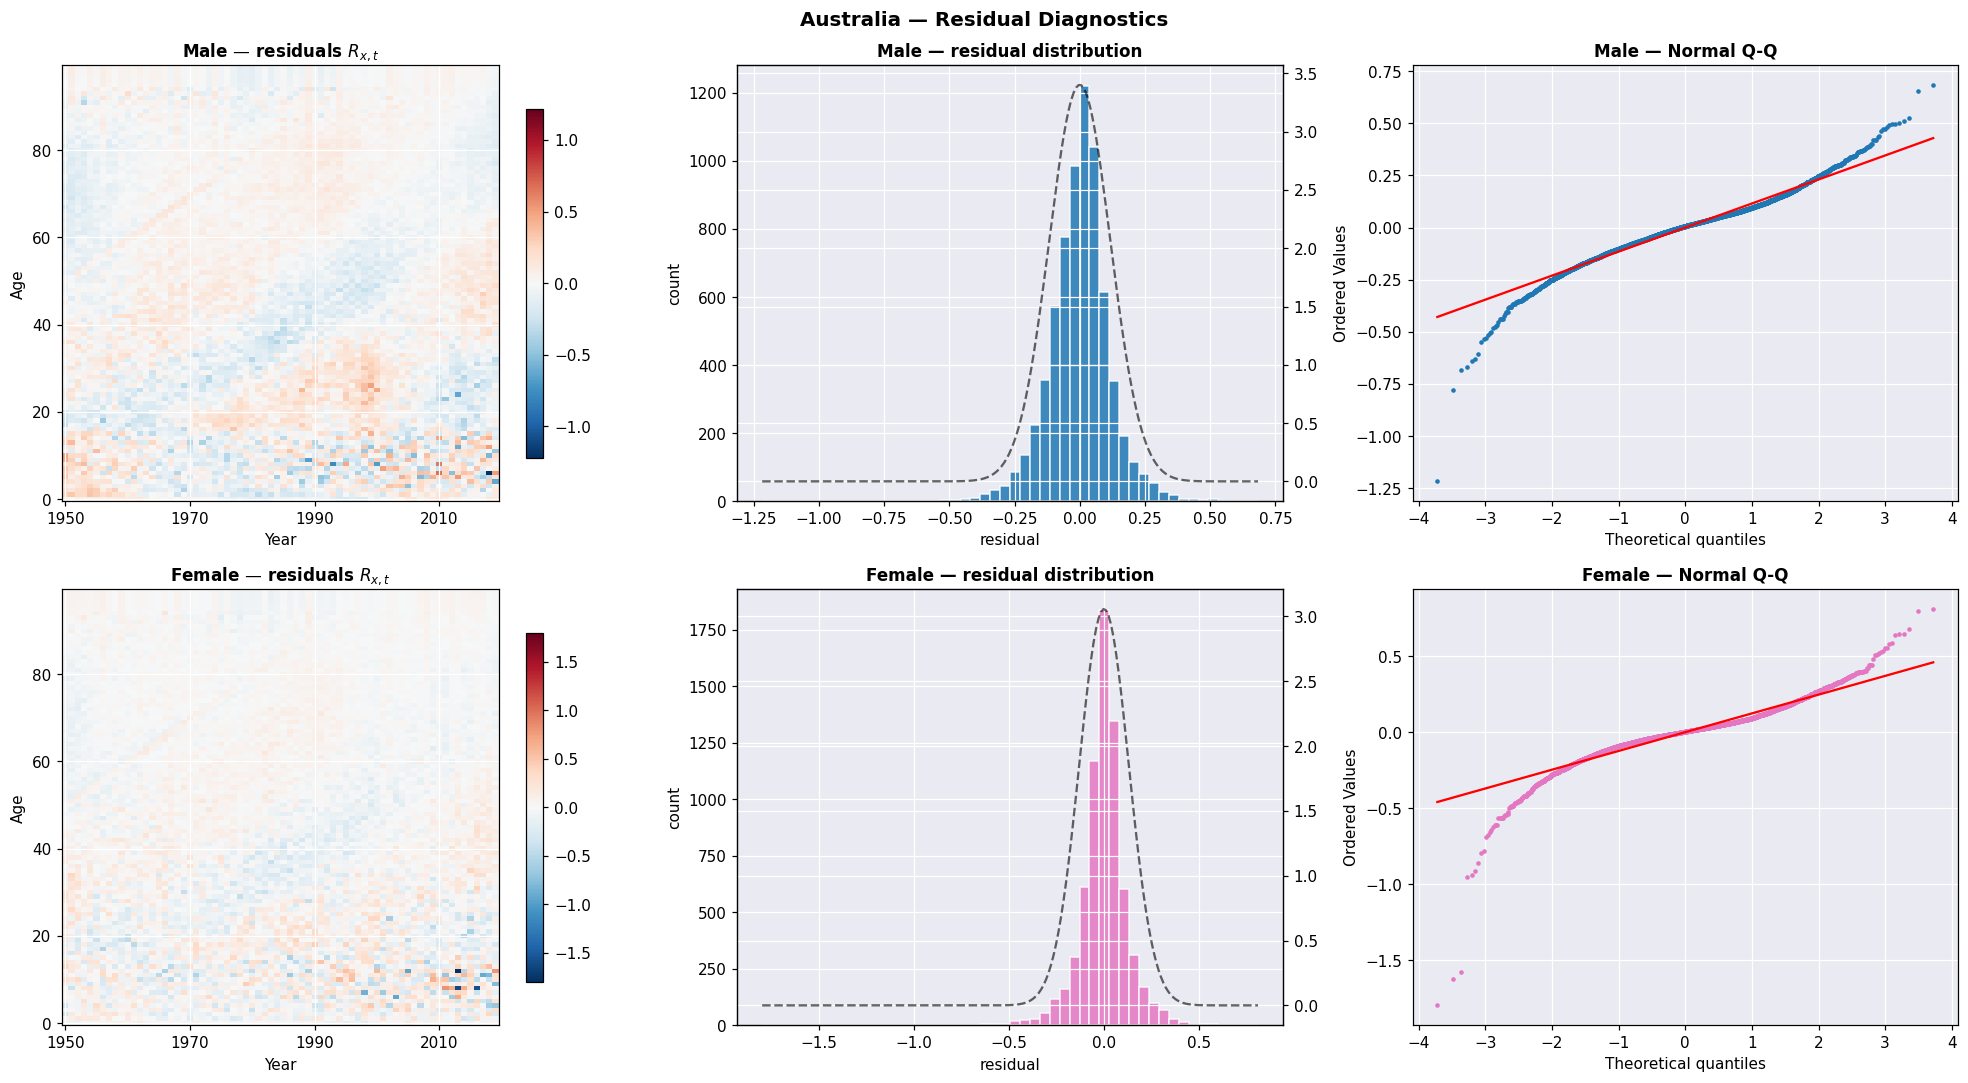

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for si, sex in enumerate(["male", "female"]):
    df   = mxt[sex]; l = lc[sex]
    lmx  = np.log(df.values)
    fit  = l["ax"].values[:, None] + np.outer(l["bx"].values, l["kt"].values)
    R    = lmx - fit
    yrs  = df.columns.to_numpy(); ages_v = df.index.to_numpy()
    ye   = np.arange(yrs[0],   yrs[-1]+2)  - 0.5
    ae   = np.arange(ages_v[0], ages_v[-1]+2) - 0.5
    ax   = axes[si]
    flat = R.flatten()

    vmax = max(np.abs(flat).max(), 1e-6)
    mesh = ax[0].pcolormesh(ye, ae, R, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    fig.colorbar(mesh, ax=ax[0], shrink=0.8)
    ax[0].set_title(f"{SEX_LABEL[sex]} — residuals $R_{{x,t}}$")
    ax[0].set_xlabel("Year"); ax[0].set_ylabel("Age")
    ax[0].set_xticks(yrs[::20]); ax[0].set_yticks(ages_v[::20])

    ax[1].hist(flat, bins=50, color=SEX_COLOR[sex], edgecolor="white", alpha=0.85)
    ax[1].set_title(f"{SEX_LABEL[sex]} — residual distribution")
    ax[1].set_xlabel("residual"); ax[1].set_ylabel("count")
    xn = np.linspace(flat.min(), flat.max(), 200)
    ax[1].twinx().plot(xn, stats.norm.pdf(xn, flat.mean(), flat.std()),
                       color="k", lw=1.5, ls="--", alpha=0.6)

    stats.probplot(flat, dist="norm", plot=ax[2])
    ax[2].set_title(f"{SEX_LABEL[sex]} — Normal Q-Q")
    ax[2].get_lines()[0].set(color=SEX_COLOR[sex], markersize=2)

    rmse = np.sqrt((R**2).mean())
    print(f"{SEX_LABEL[sex]:8s}: residual mean={flat.mean():.5f}  "
          f"std={flat.std():.4f}  RMSE={rmse:.4f}  skew={stats.skew(flat):.3f}")

plt.suptitle(f"{COUNTRY_NAME} — Residual Diagnostics", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 7. Forecasting $k_t$

We use a **random walk with drift** (RWD = ARIMA(0,1,0) + constant):
$\Delta k_t = d + \varepsilon_t$, with drift $d = \overline{\Delta k_t}$.

`auto_arima` is shown for comparison — if it selects ARIMA(0,1,0) that confirms RWD is appropriate.
White-noise residuals from Ljung-Box ($p > 0.05$) confirm the model has captured all kt structure.

In [9]:
rwd = {}
kt_fc_vals = {}

for sex in ["male", "female"]:
    kt_vals = lc[sex]["kt"].values
    auto    = pm.auto_arima(kt_vals, seasonal=False, stepwise=True,
                            suppress_warnings=True, error_action="ignore",
                            with_intercept=True, trace=False)
    model   = ARIMA(kt_vals, order=(0,1,0), trend="t").fit()
    rwd[sex] = model

    resid = model.resid[1:]
    lb    = acorr_ljungbox(resid, lags=[5,10], return_df=True)
    sw_p  = stats.shapiro(resid).pvalue

    print(f"\n{SEX_LABEL[sex]}")
    print(f"  auto_arima: ARIMA{auto.order}  (we use RWD=ARIMA(0,1,0) per LC convention)")
    print(f"  drift = {model.params[0]:.4f} per year")
    print(f"  Ljung-Box p@5={lb['lb_pvalue'].iloc[0]:.3f}  p@10={lb['lb_pvalue'].iloc[1]:.3f}")
    print(f"  Shapiro-Wilk p = {sw_p:.3f}")


Male
  auto_arima: ARIMA(2, 1, 1)  (we use RWD=ARIMA(0,1,0) per LC convention)
  drift = -1.7468 per year
  Ljung-Box p@5=0.015  p@10=0.062
  Shapiro-Wilk p = 0.390

Female
  auto_arima: ARIMA(0, 1, 1)  (we use RWD=ARIMA(0,1,0) per LC convention)
  drift = -1.9033 per year
  Ljung-Box p@5=0.021  p@10=0.005
  Shapiro-Wilk p = 0.495


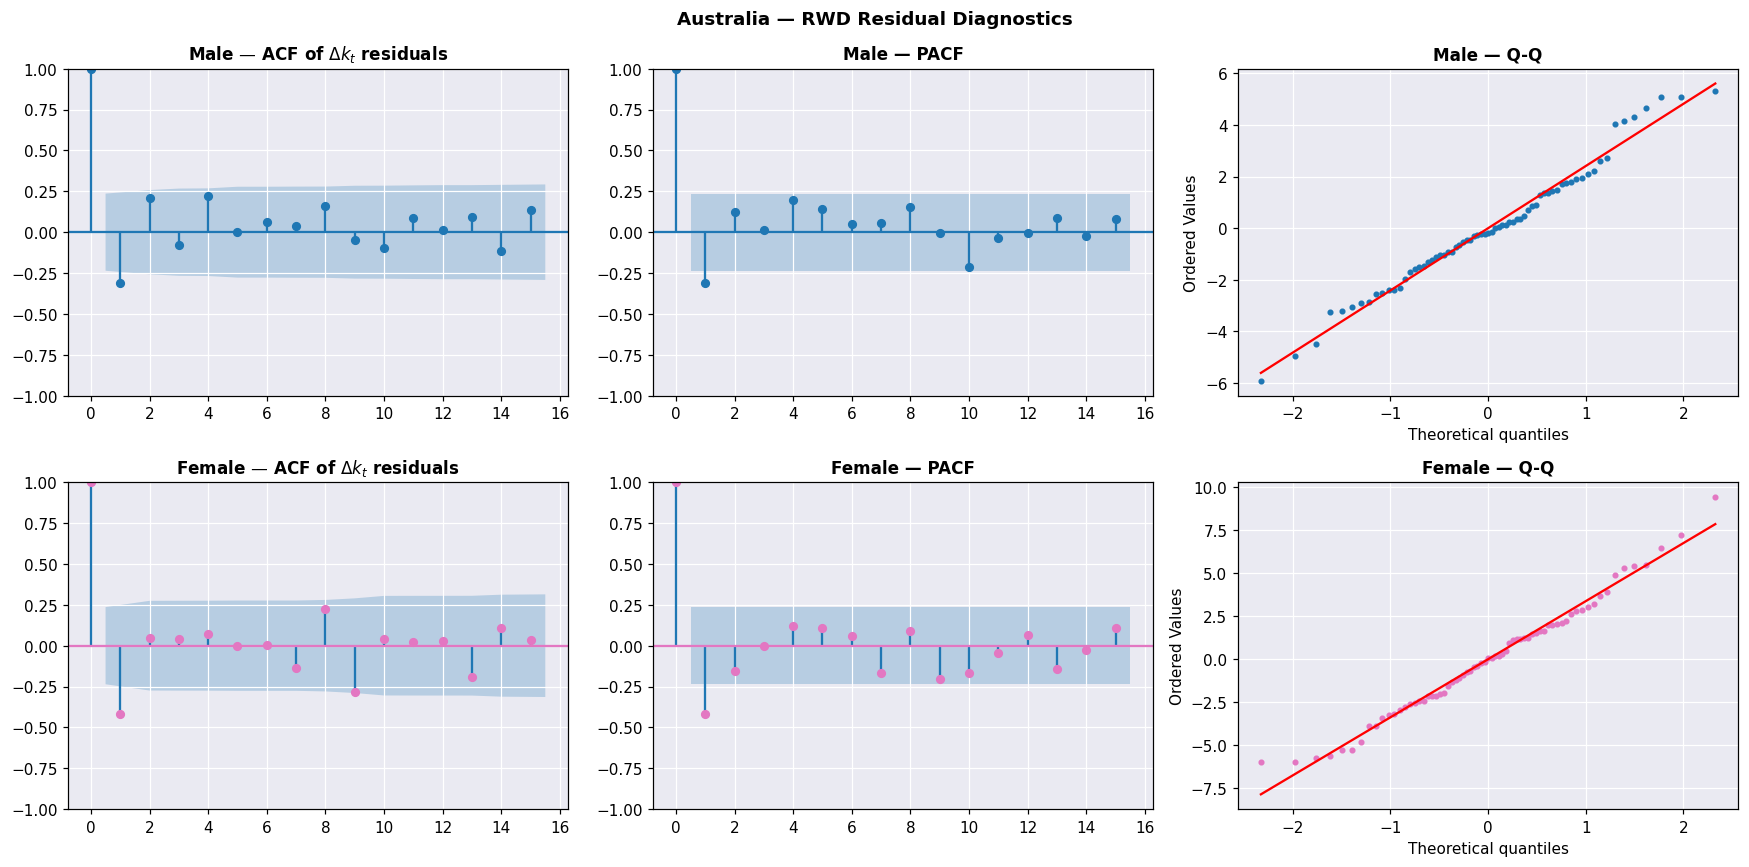

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for si, sex in enumerate(["male", "female"]):
    model   = rwd[sex]
    kt_vals = lc[sex]["kt"].values
    resid   = model.resid[1:]
    ax      = axes[si]
    col     = SEX_COLOR[sex]

    plot_acf( resid, ax=ax[0], lags=15, color=col); ax[0].set_title(f"{SEX_LABEL[sex]} — ACF of $\\Delta k_t$ residuals")
    plot_pacf(resid, ax=ax[1], lags=15, method="ywm", color=col); ax[1].set_title(f"{SEX_LABEL[sex]} — PACF")
    stats.probplot(resid, dist="norm", plot=ax[2]); ax[2].set_title(f"{SEX_LABEL[sex]} — Q-Q")
    ax[2].get_lines()[0].set(color=col, markersize=3)

plt.suptitle(f"{COUNTRY_NAME} — RWD Residual Diagnostics", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 8. $k_t$ Projection

30-year central forecast with 95% prediction interval.
The interval widens as $\sqrt{h}$ — characteristic of random-walk processes.

Male    : drift=-1.7468  k_t(2049)=-119.73  95% CI [-145.11, -94.36]
Female  : drift=-1.9033  k_t(2049)=-122.18  95% CI [-157.64, -86.72]


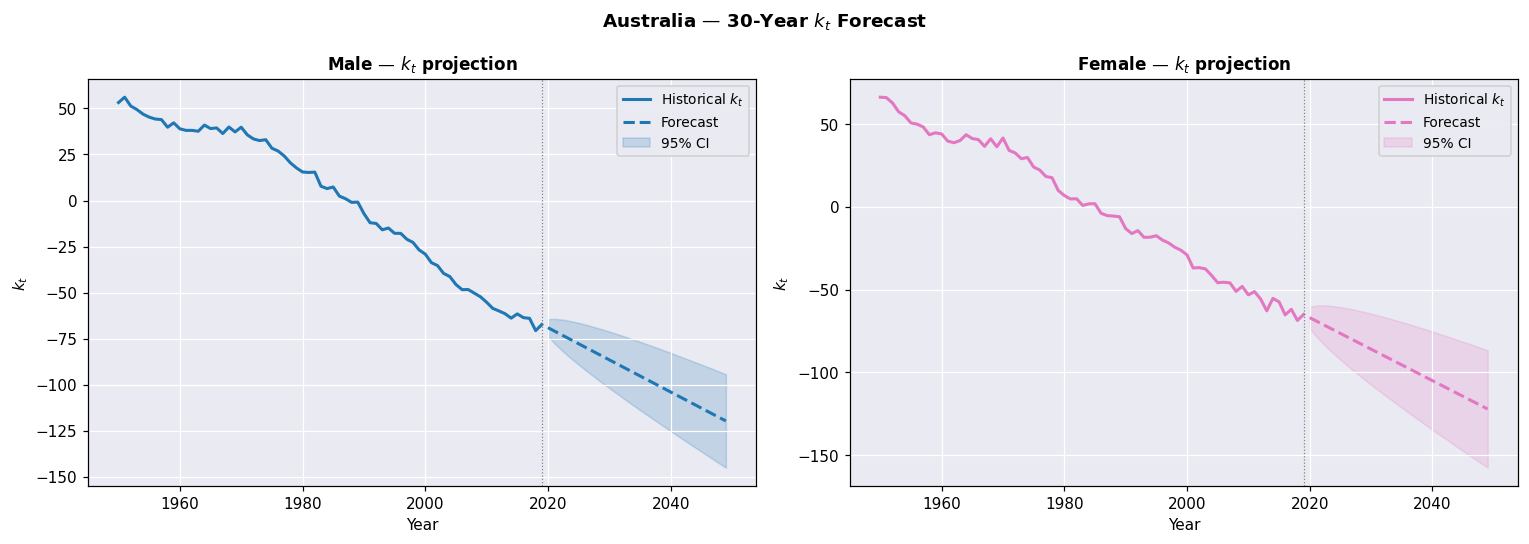

In [11]:
years_v     = lc["male"]["kt"].index.to_numpy()
future_yrs  = np.arange(YEAR_MAX + 1, YEAR_MAX + 1 + H_FORE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for si, sex in enumerate(["male", "female"]):
    ax      = axes[si]
    col     = SEX_COLOR[sex]
    model   = rwd[sex]
    kt_vals = lc[sex]["kt"].values

    fc    = model.get_forecast(steps=H_FORE)
    kf    = fc.predicted_mean
    ci    = fc.conf_int(alpha=0.05)
    klo, khi = ci[:, 0], ci[:, 1]

    kt_fc_vals[sex] = {"mean": kf, "lo": klo, "hi": khi}

    ax.plot(years_v, kt_vals, color=col, lw=2, label=r"Historical $k_t$")
    ax.plot(future_yrs, kf,   color=col, lw=2, ls="--", label="Forecast")
    ax.fill_between(future_yrs, klo, khi, color=col, alpha=0.2, label="95% CI")
    ax.axvline(YEAR_MAX, color="grey", lw=0.8, ls=":")
    ax.set(title=f"{SEX_LABEL[sex]} — $k_t$ projection",
           xlabel="Year", ylabel=r"$k_t$")
    ax.legend(fontsize=9)
    print(f"{SEX_LABEL[sex]:8s}: drift={rwd[sex].params[0]:.4f}  "
          f"k_t({future_yrs[-1]})={kf[-1]:.2f}  "
          f"95% CI [{klo[-1]:.2f}, {khi[-1]:.2f}]")

plt.suptitle(f"{COUNTRY_NAME} — 30-Year $k_t$ Forecast", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 9. Projected Mortality Rates

Back-transform $k_t$ forecast to age-specific rates:
$\hat{m}(x,t) = \exp(a_x + b_x \hat{k}_t)$.
Ages with larger $b_x$ produce wider forecast bands.

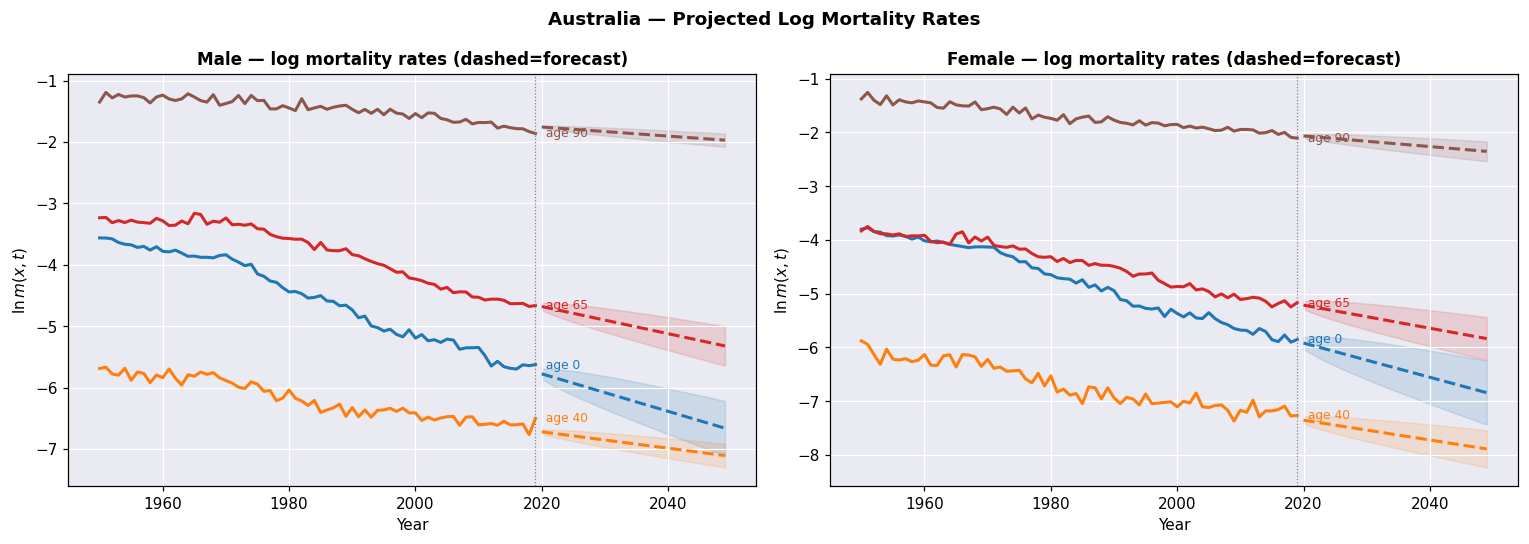

In [12]:
def project_rates(l, kt_path):
    log_p = l["ax"].values[:, None] + np.outer(l["bx"].values, np.asarray(kt_path))
    return pd.DataFrame(np.exp(log_p), index=l["ax"].index)

show_ages = [0, 40, 65, 90]
age_colors = plt.get_cmap("tab10")(np.linspace(0, 0.5, len(show_ages)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for si, sex in enumerate(["male", "female"]):
    ax  = axes[si]
    l   = lc[sex]; df = mxt[sex]
    fc  = kt_fc_vals[sex]
    pm_ = project_rates(l, fc["mean"])
    plo = project_rates(l, fc["lo"])
    phi = project_rates(l, fc["hi"])
    rl  = np.minimum(plo, phi)
    rh  = np.maximum(plo, phi)

    for i, age in enumerate(show_ages):
        c = age_colors[i]
        ax.plot(years_v, np.log(df.loc[age].values), color=c, lw=2)
        ax.plot(future_yrs, np.log(pm_.iloc[age].values), color=c, lw=2, ls="--")
        ax.fill_between(future_yrs,
                        np.log(rl.iloc[age].values),
                        np.log(rh.iloc[age].values), color=c, alpha=0.15)
        ax.text(YEAR_MAX+1, np.log(df.loc[age].values[-1]),
                f" age {age}", color=c, va="center", fontsize=8)

    ax.axvline(YEAR_MAX, color="grey", lw=0.8, ls=":")
    ax.set(title=f"{SEX_LABEL[sex]} — log mortality rates (dashed=forecast)",
           xlabel="Year", ylabel=r"$\ln m(x,t)$")

plt.suptitle(f"{COUNTRY_NAME} — Projected Log Mortality Rates", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## 10. Period Life Expectancy $e_0$

Computed from the full age schedule each year. $e_0$ CI *inverts* the rate CI:
lower rates (optimistic forecast) → higher $e_0$.

Both sexes shown on the same axes to visualise the gender gap.

In [ ]:
e0 = {}
for sex in ["male", "female"]:
    df  = mxt[sex]; l = lc[sex]; fc = kt_fc_vals[sex]
    pm_      = project_rates(l, fc["mean"])
    rates_lo = project_rates(l, fc["lo"])   # rates at lower kt CI bound
    rates_hi = project_rates(l, fc["hi"])   # rates at upper kt CI bound

    e0_hist    = [life_expectancy(df[y].values,         sex) for y in years_v]
    e0_mid     = [life_expectancy(pm_[c].values,        sex) for c in range(H_FORE)]
    e0_from_lo = [life_expectancy(rates_lo[c].values,   sex) for c in range(H_FORE)]
    e0_from_hi = [life_expectancy(rates_hi[c].values,   sex) for c in range(H_FORE)]
    # Take element-wise min/max so CI is correct even if any bx[x] < 0
    e0_lo_ = np.minimum(e0_from_lo, e0_from_hi)
    e0_hi_ = np.maximum(e0_from_lo, e0_from_hi)

    e0[sex] = {
        "hist": pd.Series(e0_hist,  index=years_v),
        "mid":  pd.Series(e0_mid,   index=future_yrs),
        "lo":   pd.Series(e0_lo_,   index=future_yrs),
        "hi":   pd.Series(e0_hi_,   index=future_yrs),
    }
    print(f"{SEX_LABEL[sex]:8s}: e0({YEAR_MAX})={e0_hist[-1]:.2f}  "
          f"e0({future_yrs[-1]})={e0_mid[-1]:.2f}  "
          f"95% CI [{e0_lo_[-1]:.2f}, {e0_hi_[-1]:.2f}]")

# Individual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for si, sex in enumerate(["male", "female"]):
    ax  = axes[si]; col = SEX_COLOR[sex]; e  = e0[sex]
    ax.plot(e["hist"].index, e["hist"].values, color=col, lw=2, label="Historical")
    ax.plot(e["mid"].index,  e["mid"].values,  color=col, lw=2, ls="--", label="Forecast")
    ax.fill_between(future_yrs, e["lo"].values, e["hi"].values, color=col, alpha=0.2, label="95% CI")
    ax.axvline(YEAR_MAX, color="grey", lw=0.8, ls=":")
    ax.set(title=f"{SEX_LABEL[sex]} — Life expectancy at birth",
           xlabel="Year", ylabel=r"$e_0$ (years)")
    ax.legend(fontsize=9)

plt.suptitle(f"{COUNTRY_NAME} — Period Life Expectancy Projections", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# Combined gender-gap plot
fig, ax = plt.subplots(figsize=(11, 5))
for sex in ["male", "female"]:
    e = e0[sex]; col = SEX_COLOR[sex]
    ax.plot(e["hist"].index, e["hist"].values, color=col, lw=2.5, label=f"{SEX_LABEL[sex]} hist.")
    ax.plot(e["mid"].index,  e["mid"].values,  color=col, lw=2.5, ls="--")
    ax.fill_between(future_yrs, e["lo"].values, e["hi"].values, color=col, alpha=0.15)
ax.axvline(YEAR_MAX, color="grey", lw=0.8, ls=":")
ax.set(title=f"{COUNTRY_NAME} — Male vs Female Life Expectancy",
       xlabel="Year", ylabel=r"$e_0$ (years)")
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

## 11. Backtesting

Train on 1950–2000; forecast 2001–2019 (19 years out-of-sample).
RMSE and MAPE computed in log-space. We also report MAE in life expectancy (years).

In [ ]:
for sex in ["male", "female"]:
    df     = mxt[sex]
    yrs_v  = df.columns.to_numpy()
    ages_v = df.index.to_numpy()

    train_yrs = [y for y in yrs_v if y <= TRAIN_END]
    test_yrs  = [y for y in yrs_v if y >  TRAIN_END]

    # Fit LC on training period
    lc_tr  = fit_lee_carter(df[train_yrs])
    rwd_tr = ARIMA(lc_tr["kt"].values, order=(0,1,0), trend="t").fit()
    kt_test = rwd_tr.get_forecast(steps=len(test_yrs)).predicted_mean

    # Reconstruct predicted log-rates
    logm_pred   = (lc_tr["ax"].values[:, None]
                   + np.outer(lc_tr["bx"].values, kt_test))
    logm_actual = np.log(df[test_yrs].values)

    err  = logm_actual - logm_pred
    rmse = np.sqrt((err**2).mean())
    mae  = np.abs(err).mean()
    # MAPE on raw death rates (dividing log-space errors by log-actuals is undefined near 0)
    mx_actual_bt = np.exp(logm_actual)
    mx_pred_bt   = np.exp(logm_pred)
    mape = (np.abs(mx_actual_bt - mx_pred_bt) / mx_actual_bt).mean() * 100
    mae_e0 = np.mean([
        abs(life_expectancy(df[y].values, sex)
            - life_expectancy(np.exp(logm_pred[:, i]), sex))
        for i, y in enumerate(test_yrs)
    ])

    print(f"{SEX_LABEL[sex]:8s}: RMSE={rmse:.4f}  MAE={mae:.4f}  "
          f"MAPE={mape:.2f}%  MAE(e0)={mae_e0:.3f} yr")

    # Plot for 4 selected ages
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ai, age in enumerate([0, 40, 65, 85]):
        axx = axes[ai//2, ai%2]
        axx.plot(yrs_v, np.log(df.loc[age].values), color="lightgrey", lw=1.5, label="Full history")
        axx.plot(train_yrs, np.log(df[train_yrs].loc[age].values),
                 color=SEX_COLOR[sex], lw=2, label=f"Train (–{TRAIN_END})")
        axx.plot(test_yrs, logm_actual[age, :], color="black", lw=2, label="Actual")
        axx.plot(test_yrs, logm_pred[age, :],   color="crimson", lw=2, ls="--", label="Predicted")
        axx.axvline(TRAIN_END, color="grey", lw=0.8, ls=":")
        axx.set(title=f"Age {age}", xlabel="Year", ylabel=r"$\ln m$")
        axx.legend(fontsize=8)
    fig.suptitle(f"{COUNTRY_NAME} {SEX_LABEL[sex]} — Backtest {TRAIN_END+1}–{YEAR_MAX}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

## 12. Bootstrap Uncertainty for $e_0$

Residual bootstrap on $k_t$ innovations:
1. Estimate drift $d = \overline{\Delta k_t}$ and residuals $\eta_t = \Delta k_t - d$.
2. For each bootstrap path: resample $\eta_t$ with replacement, cumulate to get $k_t^*$.
3. Project to mortality rates, compute $e_0^*$ for each year.

This gives empirical prediction intervals that reflect the actual distribution of
historical shocks — no normality assumption required.

Male    : e0(2049) median=85.10  95% CI [83.04, 86.68]
Female  : e0(2049) median=89.10  95% CI [86.92, 90.87]


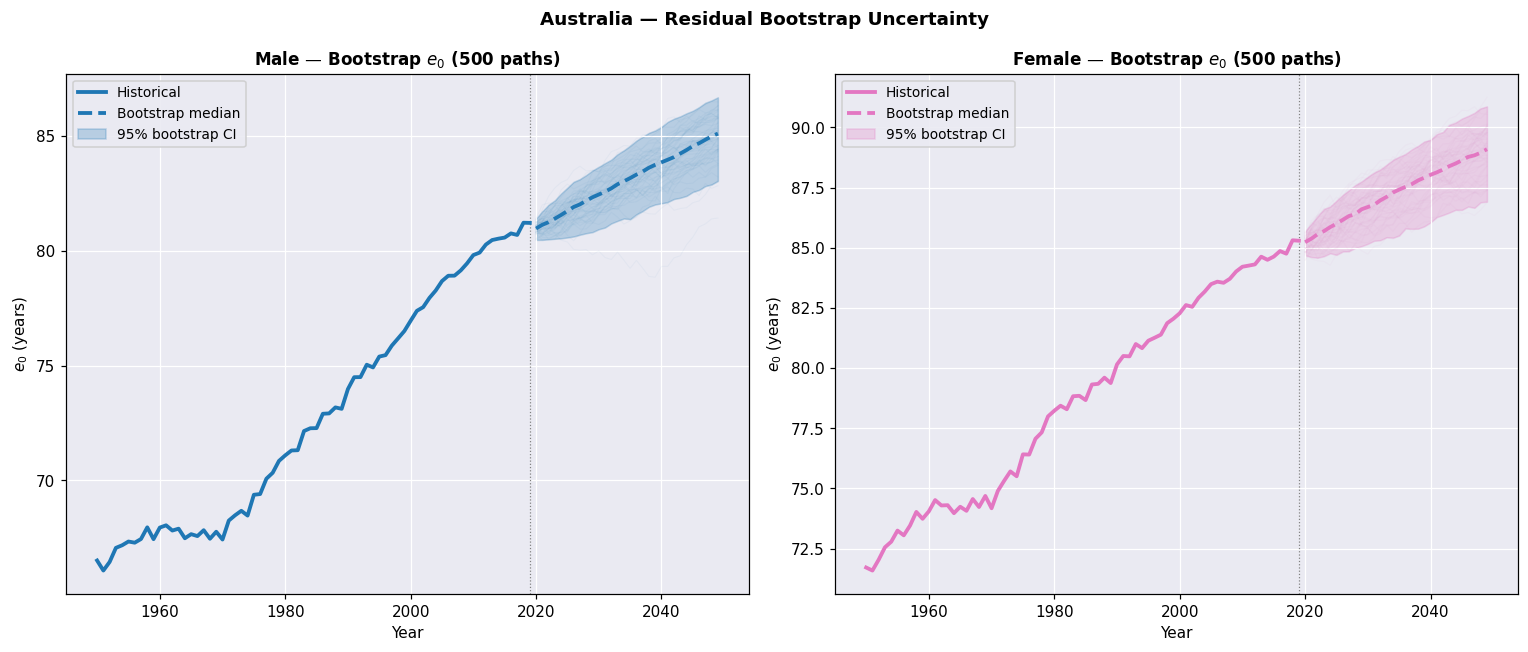

In [15]:
N_BOOT = 500

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rng = np.random.default_rng(SEED)

for si, sex in enumerate(["male", "female"]):
    ax      = axes[si]; col = SEX_COLOR[sex]
    l       = lc[sex];  df  = mxt[sex]
    kt_vals = l["kt"].values
    kt_diffs = np.diff(kt_vals)
    drift_b  = kt_diffs.mean()
    innov    = kt_diffs - drift_b
    last_kt  = kt_vals[-1]

    e0_boot = np.empty((N_BOOT, H_FORE))
    for b in range(N_BOOT):
        steps   = drift_b + rng.choice(innov, size=H_FORE, replace=True)
        kt_path = last_kt + np.cumsum(steps)
        rates_b = project_rates(l, kt_path)
        e0_boot[b] = [life_expectancy(rates_b[c].values, sex) for c in range(H_FORE)]

    e0_med  = np.median(e0_boot, axis=0)
    e0_p025 = np.percentile(e0_boot, 2.5,  axis=0)
    e0_p975 = np.percentile(e0_boot, 97.5, axis=0)

    e = e0[sex]
    ax.plot(e["hist"].index, e["hist"].values, color=col, lw=2.5, label="Historical", zorder=5)
    for b in range(0, N_BOOT, 10):
        ax.plot(future_yrs, e0_boot[b], color=col, alpha=0.04, lw=0.7)
    ax.plot(future_yrs, e0_med,  color=col, lw=2.5, ls="--", label="Bootstrap median")
    ax.fill_between(future_yrs, e0_p025, e0_p975, color=col, alpha=0.25, label="95% bootstrap CI")
    ax.axvline(YEAR_MAX, color="grey", lw=0.8, ls=":")
    ax.set(title=f"{SEX_LABEL[sex]} — Bootstrap $e_0$ ({N_BOOT} paths)",
           xlabel="Year", ylabel=r"$e_0$ (years)")
    ax.legend(fontsize=9)

    print(f"{SEX_LABEL[sex]:8s}: e0({future_yrs[-1]}) median={e0_med[-1]:.2f}  "
          f"95% CI [{e0_p025[-1]:.2f}, {e0_p975[-1]:.2f}]")

plt.suptitle(f"{COUNTRY_NAME} — Residual Bootstrap Uncertainty", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()